In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow.keras as tf
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

In [3]:
train=pd.read_csv(r'C:\Users\gaura\OneDrive\Desktop\ML Projects\annual_gold_rate.csv')
train.head()
df = pd.DataFrame({
    'Date': ['2023-12-31', '2024-12-31', '2025-12-31', '2026-12-31'],
    'USD': [2062.90, 2625.00, 2950.00, 5150.00],
    'EUR': [1866.40, 2420.00, 2714.00, 4740.00],
    'GBP': [1615.30, 2055.00, 2301.00, 4050.00],
    'INR': [171450.00, 218300.00, 251930.00, 438758.80],
    'AED': [7577.00, 9640.00, 10831.75, 18950.00],
    'CNY': [14630.00, 18720.00, 21476.00, 37200.00],

}, index=[43, 44, 45, 46])
train_new=pd.concat([train,df],axis=0)
train_new.describe()

,USD,EUR,GBP,INR,AED,CNY
count,47.000000,47.000000,47.000000,47.000000,47.000000,42.000000
mean,947.666596,814.949470,660.852869,57070.868082,3481.593144,6840.552403
std,914.986073,833.332894,730.365001,81914.727597,3363.907778,6821.766267
min,271.040000,253.370850,172.110000,3553.626800,995.520000,926.645180
25%,365.585000,320.265030,225.169740,8931.344560,1343.192370,2307.205000
50%,446.220000,394.089220,269.815530,16905.930000,1641.523380,4226.415000
75%,1267.445000,1093.900000,938.325000,82047.615000,4655.330000,8634.975000
max,5150.000000,4740.000000,4050.000000,438758.800000,18950.000000,37200.000000


In [4]:
train_new.info()


<class 'pandas.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    47 non-null     str    
 1   USD     47 non-null     float64
 2   EUR     47 non-null     float64
 3   GBP     47 non-null     float64
 4   INR     47 non-null     float64
 5   AED     47 non-null     float64
 6   CNY     42 non-null     float64
dtypes: float64(6), str(1)
memory usage: 2.7 KB


In [5]:
cny_values = [920.949, 784.011, 710.568, 836.399, 836.049]
train_new.loc[0:4, 'CNY'] = cny_values
train_new.head()

,Date,USD,EUR,GBP,INR,AED,CNY
0,1980-12-31,614.50,378.19461,263.80259,4831.74943,2278.36795,920.949
1,1981-12-31,459.26,360.90588,227.01948,3966.64790,1691.03194,784.011
2,1982-12-31,375.30,345.59742,215.53232,3553.62680,1378.72895,710.568
3,1983-12-30,423.66,439.89318,279.24936,4270.42821,1557.45790,836.399
4,1984-12-31,360.78,425.91000,269.81553,4067.60433,1324.72272,836.049


In [6]:
# Step 1 — convert to datetime first
train_new['Date'] = pd.to_datetime(train_new['Date'])

# Step 2 — now extract year
train_new['Year'] = train_new['Date'].dt.year
train_new.drop('Date',inplace=True,axis=1)

In [77]:
df=train_new
Y=train_new.drop('Year',axis=1)
X=train_new['Year']
X.shape


(47,)

In [92]:
model=Sequential([
    Dense(units=128,input_shape=(1,),activation='relu'),
    Dense(units=64,activation='relu'),
    Dense(units=32,activation='relu'),
    Dense(units=16,activation='relu'),
    Dense(units=6,activation='linear'),
])
X_mean=np.mean(X,axis=0)
X_std=np.std(X,axis=0)
X_scaled=(X-X_mean)/X_std

Y_mean=np.mean(Y,axis=0)
Y_std=np.std(Y,axis=0)
Y_scaled=(Y-Y_mean)/Y_std

model.compile(loss=MeanSquaredError(),optimizer=Adam(learning_rate=0.01))

model.fit(X_scaled, Y_scaled,
          epochs=1000,        
          verbose=0)

X_test=np.array([2027,2028,2029,2030,2031,2032,2033,2034,2035,2036,2037,2038,2039,2040])

X_test_Scaled=(X_test-X_mean)/X_std

predictions=model.predict(X_test_Scaled)
Y_mean = np.array(Y_mean)
Y_std = np.array(Y_std)

predictions = model.predict(X_test_Scaled)
predictions = predictions * Y_std + Y_mean



c:\Users\gaura\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


In [93]:
USD=[]
EUR=[]	
GBP=[]
INR=[]	
AED=[]	
CNY=[]
for pred in predictions:
    USD.append(pred[0]/31.1)
    EUR.append(pred[1]/31.1)	
    GBP.append(pred[2]/31.1)
    INR.append(pred[3]/31.1)
    AED.append(pred[4]/31.1)
    CNY.append(pred[5]/31.1)

submission=pd.DataFrame({
    'Year':X_test,
    'USD':USD,
    'EUR':EUR,
    'GBP':GBP,
    'INR':INR,
    'AED':AED,
    'CNY':CNY,
})
submission


,Year,USD,EUR,GBP,INR,AED,CNY
0,2027,198.484085,183.454777,156.873746,17006.322365,740.485276,1455.828117
1,2028,234.574940,217.455555,185.806479,20178.238556,879.792903,1728.931734
2,2029,273.131015,253.661211,216.792595,23552.861148,1030.603217,2023.475493
3,2030,310.435841,288.772694,246.830837,26838.113355,1175.972164,2308.071350
4,2031,348.483131,324.747183,277.684410,30217.153089,1325.615279,2600.665783
5,2032,385.620717,359.865948,307.798584,33516.577423,1471.572138,2886.134090
6,2033,425.807685,397.921161,340.436721,37096.285833,1629.660211,3195.376702
7,2034,471.576985,440.849421,377.357793,41115.064293,1809.612127,3546.968027
8,2035,520.289633,486.125040,416.372008,45334.571070,2000.548316,3919.875656
9,2036,569.012080,531.409760,455.394044,49554.937667,2191.522365,4292.858381


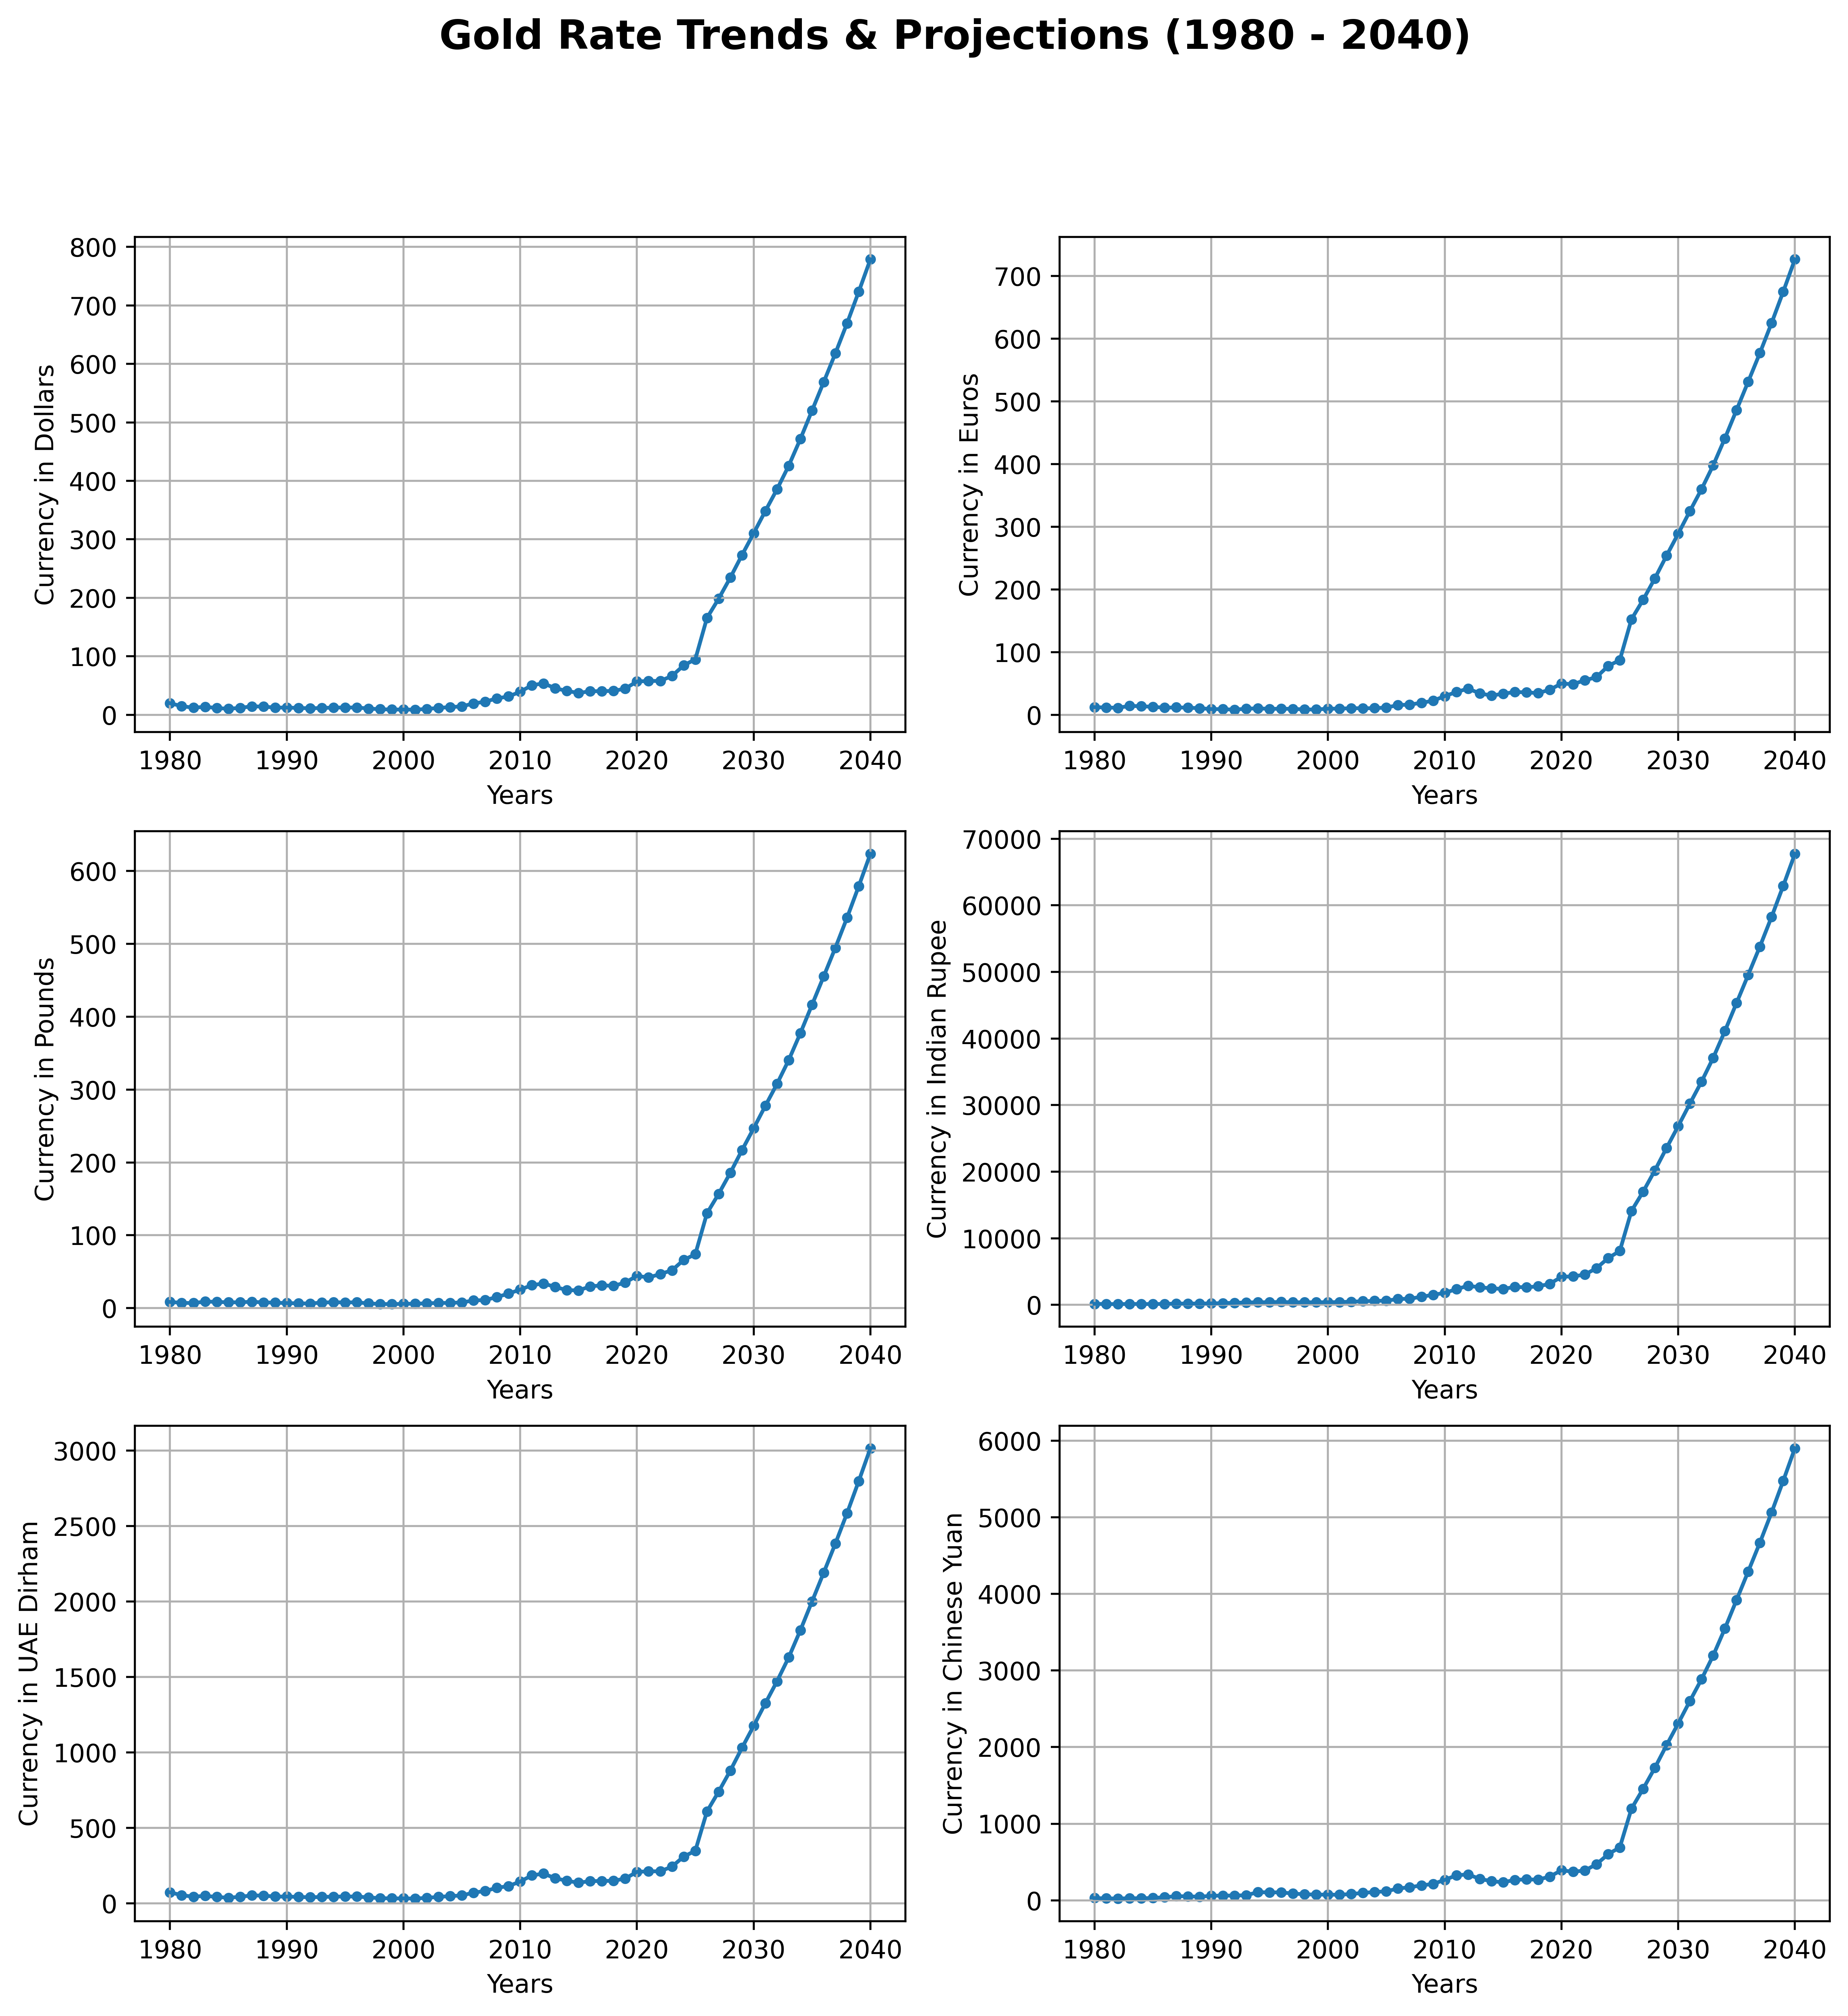

In [101]:
preY=submission.drop(['Year'],axis=1)
preY
preX=submission['Year']
preX
X_Plot=pd.concat([X,preX],axis=0).reset_index(drop=True)
X_Plot
Y_plot=pd.concat([Y/31.1,preY],axis=0).reset_index(drop=True)
Y_plot
plt.figure(figsize=(12,12),dpi=500)
plt.suptitle('Gold Rate Trends & Projections (1980 - 2040)', fontsize=16, fontweight='bold', y=0.98)
plt.subplot(3,2,1)
plt.scatter(X_Plot,Y_plot['USD'],s=10)
plt.plot(X_Plot,Y_plot['USD'])
plt.xlabel("Years")
plt.ylabel("Currency in Dollars")
plt.grid(True)
plt.subplot(3,2,2)
plt.scatter(X_Plot,Y_plot['EUR'],s=10)
plt.plot(X_Plot,Y_plot['EUR'])
plt.xlabel("Years")
plt.ylabel("Currency in Euros")
plt.grid(True)
plt.subplot(3,2,3)
plt.scatter(X_Plot,Y_plot['GBP'],s=10)
plt.plot(X_Plot,Y_plot['GBP'])
plt.xlabel("Years")
plt.ylabel("Currency in Pounds")
plt.grid(True)
plt.subplot(3,2,4)
plt.scatter(X_Plot,Y_plot['INR'],s=10)
plt.plot(X_Plot,Y_plot['INR'])
plt.xlabel("Years")
plt.ylabel("Currency in Indian Rupee")
plt.grid(True)
plt.subplot(3,2,5)
plt.scatter(X_Plot,Y_plot['AED'],s=10)
plt.plot(X_Plot,Y_plot['AED'])
plt.xlabel("Years")
plt.ylabel("Currency in UAE Dirham")
plt.grid(True)
plt.subplot(3,2,6)
plt.scatter(X_Plot,Y_plot['CNY'],s=10)
plt.plot(X_Plot,Y_plot['CNY'])
plt.xlabel("Years")
plt.ylabel("Currency in Chinese Yuan")
plt.grid(True)

plt.savefig('Gold_Rate.png')